# DATASET SACADO DE KAGGLE (https://www.kaggle.com/datasets/eoinamoore/historical-nba-data-and-player-box-scores)

In [1]:
# Librerías
import polars as pl
import polars.selectors as cs
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.getcwd()

# Configurar visualización amplia 
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(300)
pl.Config.set_fmt_str_lengths(150)
pl.Config.set_tbl_rows(10)

polars.config.Config

### Cargamos el Dataset como LazyFrame

In [2]:
# Install dependencies as needed:
# pip install kagglehub[polars-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "LeagueSchedule25_26.csv"

# Load the latest version
lf = kagglehub.load_dataset(
  KaggleDatasetAdapter.POLARS,
  "eoinamoore/historical-nba-data-and-player-box-scores",
  file_path,
)

print("First 5 records:", lf.collect().head())

/tmp/ipykernel_723029/1951115132.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  lf = kagglehub.load_dataset(


First 5 records: shape: (5, 17)
┌──────────┬─────────────────────┬────────────┬────────────┬──────────────┬──────────────┬──────────────┬────────────────┬─────────┬─────────────────┬─────────────┬────────────┬───────────┬────────────────────┬──────────────┬──────────────────┬────────────┐
│ gameId   ┆ gameDateTimeEst     ┆ homeTeamId ┆ awayTeamId ┆ homeTeamCity ┆ homeTeamName ┆ awayTeamCity ┆ awayTeamName   ┆ gameDay ┆ arenaName       ┆ arenaCity   ┆ arenaState ┆ gameLabel ┆ gameSubLabel       ┆ gameSubtype  ┆ seriesGameNumber ┆ weekNumber │
│ ---      ┆ ---                 ┆ ---        ┆ ---        ┆ ---          ┆ ---          ┆ ---          ┆ ---            ┆ ---     ┆ ---             ┆ ---         ┆ ---        ┆ ---       ┆ ---                ┆ ---          ┆ ---              ┆ ---        │
│ i64      ┆ str                 ┆ i64        ┆ i64        ┆ str          ┆ str          ┆ str          ┆ str            ┆ str     ┆ str             ┆ str         ┆ str        ┆ str       ┆ str 

### Analisis de Datos

In [3]:
# Visualizamos los datos con LazyFrame
lf.collect()

gameId,gameDateTimeEst,homeTeamId,awayTeamId,homeTeamCity,homeTeamName,awayTeamCity,awayTeamName,gameDay,arenaName,arenaCity,arenaState,gameLabel,gameSubLabel,gameSubtype,seriesGameNumber,weekNumber
i64,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,i64
12500008,"""2025-10-02 12:00:00""",1610612752,1610612755,"""New York""","""Knicks""","""Philadelphia""","""76ers""","""Thu""","""Etihad Arena""","""Abu Dhabi""","""""","""Preseason""","""NBA Abu Dhabi Game""","""Global Games""",null,null
12500009,"""2025-10-03 05:30:00""",1610612740,15016,"""New Orleans""","""Pelicans""","""Melbourne""","""United""","""Fri""","""Rod Laver Arena""","""Melbourne""","""""","""Preseason""","""NBA Melbourne Game""",null,null,null
12500001,"""2025-10-03 22:00:00""",1610612747,1610612756,"""Los Angeles""","""Lakers""","""Phoenix""","""Suns""","""Fri""","""Acrisure Arena""","""Palm Desert""","""CA""","""Preseason""",null,null,null,null
12500010,"""2025-10-04 11:00:00""",1610612755,1610612752,"""Philadelphia""","""76ers""","""New York""","""Knicks""","""Sat""","""Etihad Arena""","""Abu Dhabi""","""""","""Preseason""","""NBA Abu Dhabi Game""","""Global Games""",null,null
12500026,"""2025-10-04 20:00:00""",1610612751,50014,"""Brooklyn""","""Nets""","""Hapoel""","""Jerusalem B.C.""","""Sat""","""Barclays Center""","""Brooklyn""","""NY""","""Preseason""",null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
52500211,"""2026-04-17 00:00:00""",0,0,null,null,null,null,"""Fri""","""""","""""","""""","""SoFi Play-In Tournament""","""West""",null,null,26
42500401,"""2026-06-03 20:30:00""",0,0,null,null,null,null,"""Wed""","""""","""""","""""","""NBA Finals""","""Game 1""",null,"""Game 1""",33
42500402,"""2026-06-05 20:30:00""",0,0,null,null,null,null,"""Fri""","""""","""""","""""","""NBA Finals""","""Game 2""",null,"""Game 2""",33


In [4]:
lf.schema

/tmp/ipykernel_723029/2177650233.py:1: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  lf.schema


Schema([('gameId', Int64),
        ('gameDateTimeEst', String),
        ('homeTeamId', Int64),
        ('awayTeamId', Int64),
        ('homeTeamCity', String),
        ('homeTeamName', String),
        ('awayTeamCity', String),
        ('awayTeamName', String),
        ('gameDay', String),
        ('arenaName', String),
        ('arenaCity', String),
        ('arenaState', String),
        ('gameLabel', String),
        ('gameSubLabel', String),
        ('gameSubtype', String),
        ('seriesGameNumber', String),
        ('weekNumber', Int64)])

In [5]:
lf.describe()

statistic,gameId,gameDateTimeEst,homeTeamId,awayTeamId,homeTeamCity,homeTeamName,awayTeamCity,awayTeamName,gameDay,arenaName,arenaCity,arenaState,gameLabel,gameSubLabel,gameSubtype,seriesGameNumber,weekNumber
str,f64,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,f64
"""count""",1319.0,"""1319""",1319.0,1319.0,"""1309""","""1309""","""1309""","""1309""","""1319""","""1319""","""1319""","""1319""","""170""","""85""","""74""","""4""",1248.0
"""null_count""",0.0,"""0""",0.0,0.0,"""10""","""10""","""10""","""10""","""0""","""0""","""0""","""0""","""1149""","""1234""","""1245""","""1315""",71.0
"""mean""",2.2243e7,null,1.5984e9,1.5911e9,null,null,null,null,null,null,null,null,null,null,null,null,13.342147
"""std""",3.5181e6,null,1.3976e8,1.7638e8,null,null,null,null,null,null,null,null,null,null,null,null,7.420625
"""min""",1.2500001e7,"""2025-10-02 12:00:00""",0.0,0.0,"""""","""76ers""","""""","""76ers""","""Fri""","""""","""""","""""","""AWS NBA Rivals Week""","""Championship""","""Global Games""","""Game 1""",1.0
"""25%""",2.250026e7,null,1.6106e9,1.6106e9,null,null,null,null,null,null,null,null,null,null,null,null,7.0
"""50%""",2.2500589e7,null,1.6106e9,1.6106e9,null,null,null,null,null,null,null,null,null,null,null,null,13.0
"""75%""",2.2500919e7,null,1.6106e9,1.6106e9,null,null,null,null,null,null,null,null,null,null,null,null,20.0
"""max""",6.2500001e7,"""2026-06-10 20:30:00""",1.6106e9,1.6106e9,"""Washington""","""Wizards""","""Washington""","""World""","""Wed""","""Xfinity Mobile Arena""","""Washington""","""WI""","""SoFi Play-In Tournament""","""West Semifinal""","""in-season-knockout""","""Game 4""",34.0


In [6]:
lf.null_count().collect()

gameId,gameDateTimeEst,homeTeamId,awayTeamId,homeTeamCity,homeTeamName,awayTeamCity,awayTeamName,gameDay,arenaName,arenaCity,arenaState,gameLabel,gameSubLabel,gameSubtype,seriesGameNumber,weekNumber
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,10,10,10,10,0,0,0,0,1149,1234,1245,1315,71


In [7]:
# Filtrar filas con al menos un nulo
filas_con_nulos = lf.filter(
    pl.any_horizontal(pl.all().is_null())
)

# Ejecutar y ver resultado (primeras 10 filas, por ejemplo)
print(filas_con_nulos.collect())

shape: (1_319, 17)
┌──────────┬─────────────────────┬────────────┬────────────┬──────────────┬──────────────┬──────────────┬────────────────┬─────────┬─────────────────┬─────────────┬────────────┬─────────────────────────┬────────────────────┬──────────────┬──────────────────┬────────────┐
│ gameId   ┆ gameDateTimeEst     ┆ homeTeamId ┆ awayTeamId ┆ homeTeamCity ┆ homeTeamName ┆ awayTeamCity ┆ awayTeamName   ┆ gameDay ┆ arenaName       ┆ arenaCity   ┆ arenaState ┆ gameLabel               ┆ gameSubLabel       ┆ gameSubtype  ┆ seriesGameNumber ┆ weekNumber │
│ ---      ┆ ---                 ┆ ---        ┆ ---        ┆ ---          ┆ ---          ┆ ---          ┆ ---            ┆ ---     ┆ ---             ┆ ---         ┆ ---        ┆ ---                     ┆ ---                ┆ ---          ┆ ---              ┆ ---        │
│ i64      ┆ str                 ┆ i64        ┆ i64        ┆ str          ┆ str          ┆ str          ┆ str            ┆ str     ┆ str             ┆ str         ┆ 

### Creamos el Dataframe para limpiarlo

In [8]:
df_schedule = lf.collect()
df_schedule.head(2)

gameId,gameDateTimeEst,homeTeamId,awayTeamId,homeTeamCity,homeTeamName,awayTeamCity,awayTeamName,gameDay,arenaName,arenaCity,arenaState,gameLabel,gameSubLabel,gameSubtype,seriesGameNumber,weekNumber
i64,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,i64
12500008,"""2025-10-02 12:00:00""",1610612752,1610612755,"""New York""","""Knicks""","""Philadelphia""","""76ers""","""Thu""","""Etihad Arena""","""Abu Dhabi""","""""","""Preseason""","""NBA Abu Dhabi Game""","""Global Games""",null,null
12500009,"""2025-10-03 05:30:00""",1610612740,15016,"""New Orleans""","""Pelicans""","""Melbourne""","""United""","""Fri""","""Rod Laver Arena""","""Melbourne""","""""","""Preseason""","""NBA Melbourne Game""",null,null,null


In [9]:
# Eliminamos columnas que no aportan información relevante para el análisis
Columnas_a_eliminar = ["seriesGameNumber", "gameSubtype", "gameLabel", "gameSubLabel"]

df_schedule = df_schedule.drop(Columnas_a_eliminar)


In [10]:
df_schedule =df_schedule.drop_nulls()
df_schedule.null_count()

gameId,gameDateTimeEst,homeTeamId,awayTeamId,homeTeamCity,homeTeamName,awayTeamCity,awayTeamName,gameDay,arenaName,arenaCity,arenaState,weekNumber
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0


### Outliers

gameId


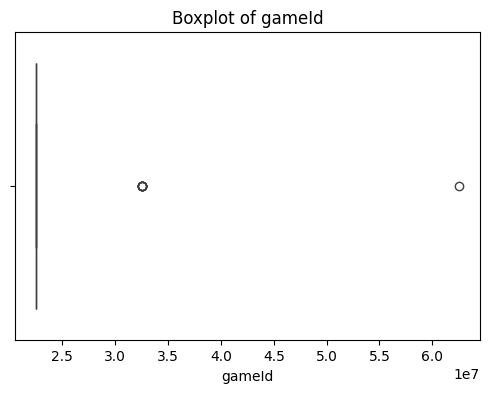

homeTeamId


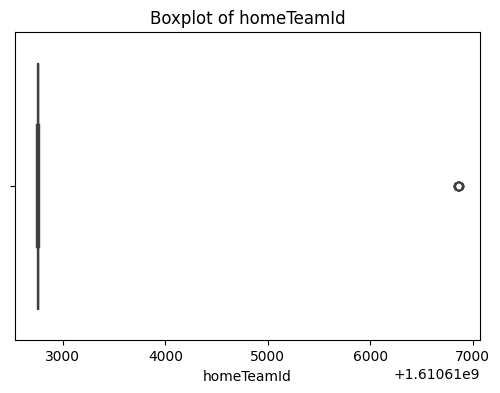

awayTeamId


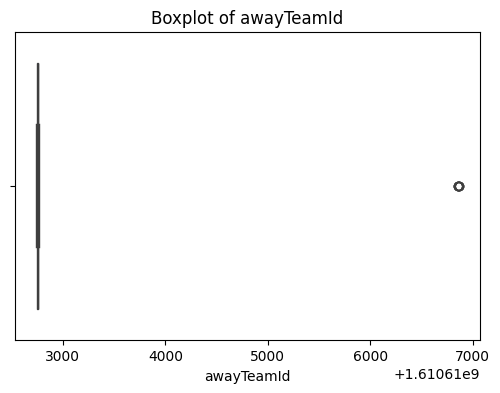

weekNumber


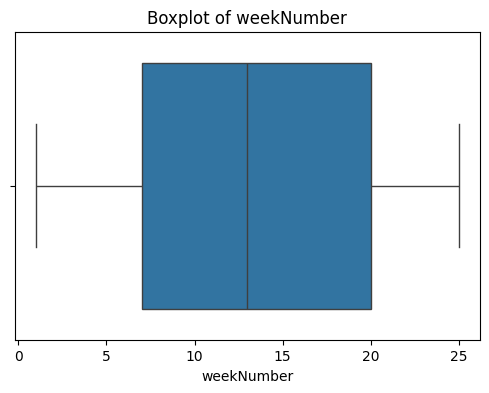

In [11]:
numeric_cols = df_schedule.select(cs.numeric()).columns


for col in numeric_cols:
    # Boxplot
    print(col)
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_schedule[col])
    plt.title(f'Boxplot of {col}')
    plt.show()